In [26]:
library(tidyverse)
library(tsibble)
library(fable)
library(fabletools)
library(feasts)
library(lubridate)

options(repr.plot.width = 12, repr.plot.height = 5, repr.plot.res = 150)

In [27]:
# Load pre-cleaned data (produced by data_cleaning.ipynb)
df_lagged  <- readr::read_rds("fluview_clean/df_lagged.rds")
train_full <- readr::read_rds("fluview_clean/train_full.rds")
holdout    <- readr::read_rds("fluview_clean/holdout.rds")
n_train_init <- nrow(train_full)

cat("Rows:", nrow(df_lagged), "\n")
cat("Holdout range:", as.character(min(holdout$week_start)),
    "to", as.character(max(holdout$week_start)), "\n")

Rows: 1198 
Holdout range: 2023 W01 to 2024 W52 


In [28]:
rolling_rmse <- function(data, model_expr, model_name, min_train = n_train_init) {

  stretched <- data %>%
    stretch_tsibble(.init = min_train, .step = 1)

  rolling_fits <- rlang::inject(
    model(stretched, mod = !!model_expr)
  )

  rolling_fc <- rolling_fits %>%
    forecast(h = 1)

  actuals <- data %>%
    as_tibble() %>%
    select(week_start, actual = percent_weighted_ili)

  results <- rolling_fc %>%
    as_tibble() %>%
    left_join(actuals, by = "week_start") %>%
    mutate(
      model    = model_name,
      forecast = .mean,
      sq_error = (actual - forecast)^2
    ) %>%
    select(model, week_start, actual, forecast, sq_error)

  results
}

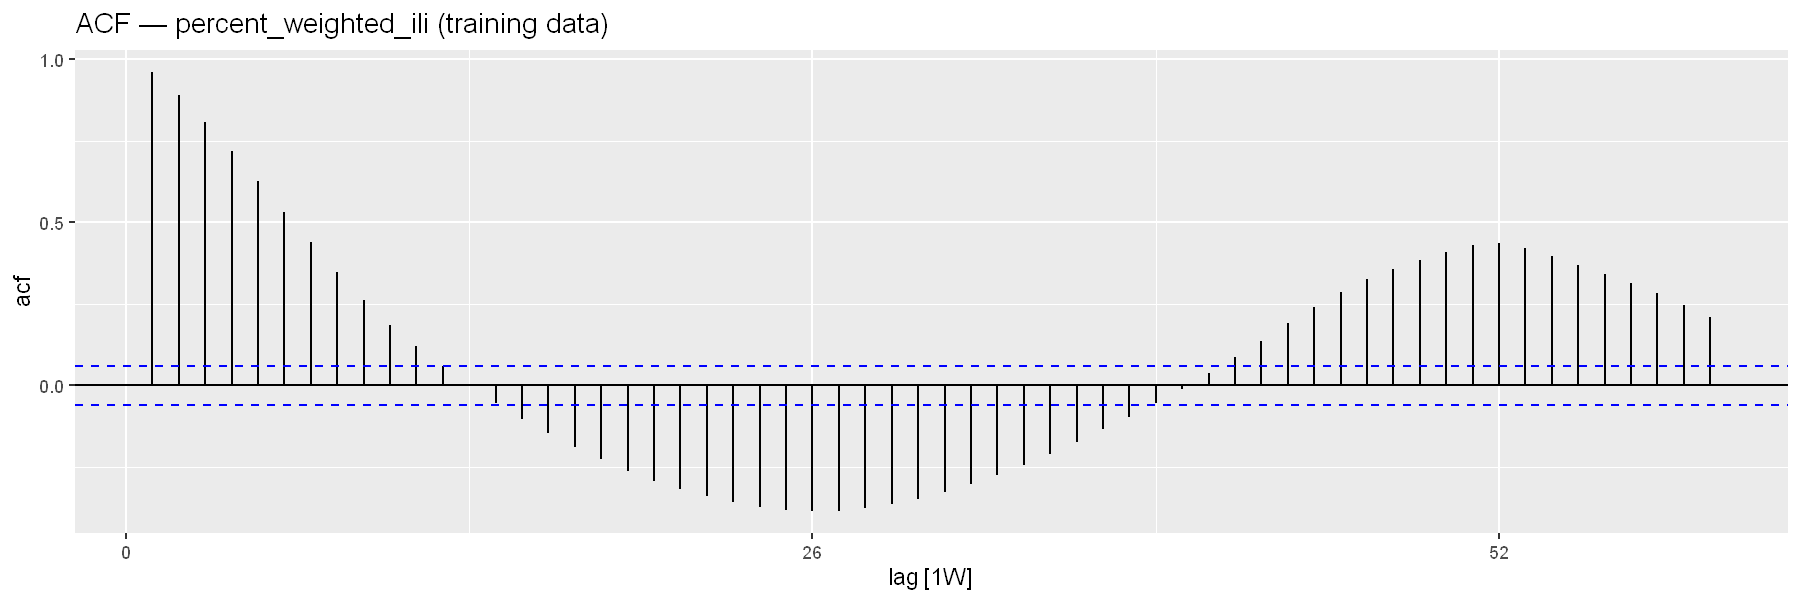

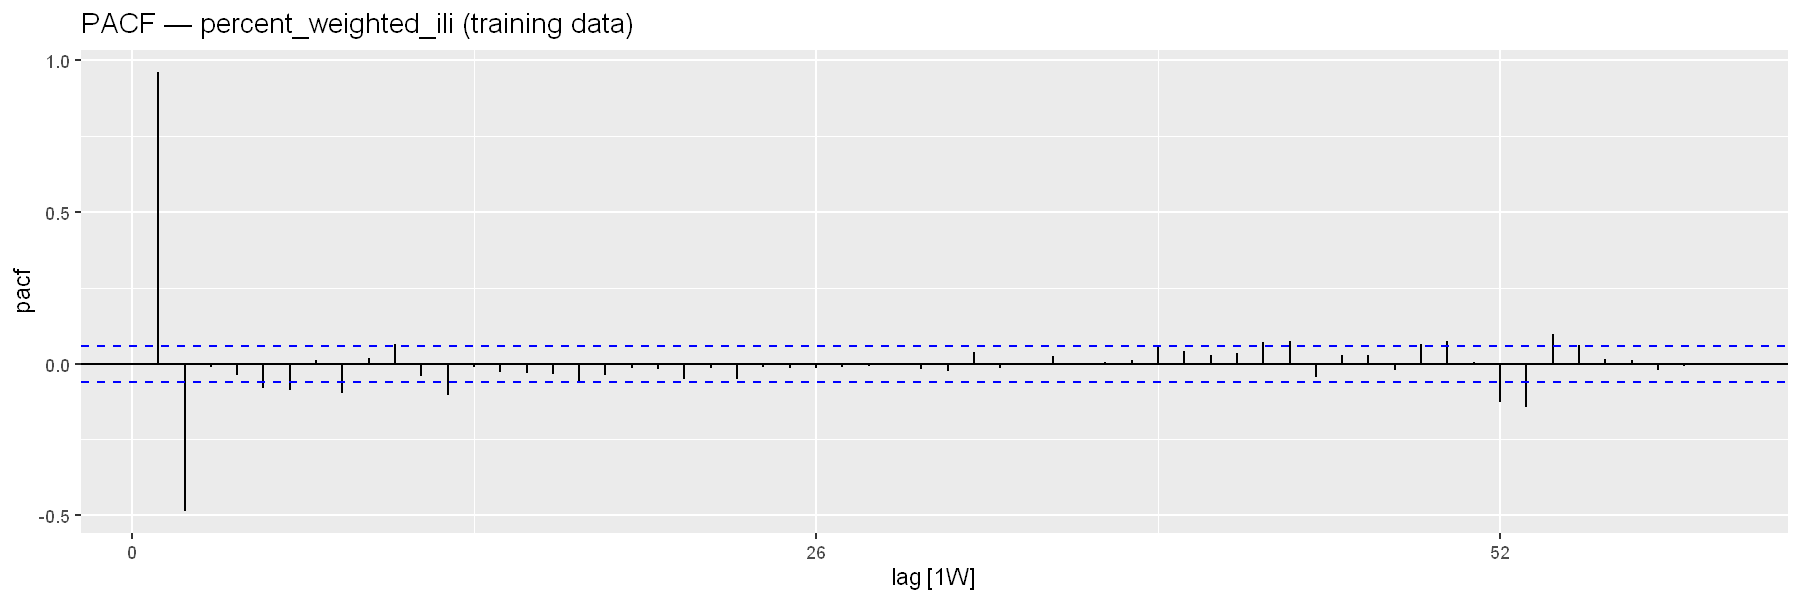

In [29]:
# ── ACF / PACF on training data (order identification) ──────────────────────
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 150)

train_full %>%
  ACF(percent_weighted_ili, lag_max = 60) %>%
  autoplot() +
  labs(title = "ACF — percent_weighted_ili (training data)")

train_full %>%
  PACF(percent_weighted_ili, lag_max = 60) %>%
  autoplot() +
  labs(title = "PACF — percent_weighted_ili (training data)")

In [30]:
rolling_rmse <- function(data, model_expr, model_name, min_train = n_train_init) {

  stretched <- data %>%
    stretch_tsibble(.init = min_train, .step = 1)

  rolling_fits <- rlang::inject(
    model(stretched, mod = !!model_expr)
  )

  rolling_fc <- rolling_fits %>%
    forecast(h = 1)

  actuals <- data %>%
    as_tibble() %>%
    select(week_start, actual = percent_weighted_ili)

  results <- rolling_fc %>%
    as_tibble() %>%
    left_join(actuals, by = "week_start") %>%
    mutate(
      model    = model_name,
      forecast = .mean,
      sq_error = (actual - forecast)^2
    ) %>%
    select(model, week_start, actual, forecast, sq_error)

  results
}

In [31]:
# Fit on your training data
fit <- train_full %>%
  model(arima_auto = ARIMA(percent_weighted_ili))

# See what it picked
report(fit)

Series: percent_weighted_ili 
Model: ARIMA(0,1,2)(2,0,0)[52] 

Coefficients:
         ma1     ma2    sar1    sar2
      0.4518  0.1918  0.2261  0.1959
s.e.  0.0296  0.0298  0.0309  0.0339

sigma^2 estimated as 0.08683:  log likelihood=-217.67
AIC=445.34   AICc=445.39   BIC=470.32


### Without Seasonality

In [32]:
cat("Fitting rolling ARIMA...\n")
res_arima <- rolling_rmse(
  df_lagged,
  expr(ARIMA(percent_weighted_ili ~ pdq(1,1,2) + PDQ(0,0,0) + 0)),
  "ARIMA"
)

Fitting rolling ARIMA...


### With Seasonality

In [33]:
cat("Fitting rolling ARIMA...\n")
res_arima2 <- rolling_rmse(
  df_lagged,
  expr(ARIMA(percent_weighted_ili ~ pdq(1,1,2) + PDQ(2,0,0))),
  "ARIMA"
)

Fitting rolling ARIMA...


Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIM

### Seasonality Results

In [34]:
# Compare seasonal vs non-seasonal ARIMA
arima_seasonal_comparison <- bind_rows(
  res_arima  %>%
    filter(week_start %in% holdout$week_start) %>%
    summarise(
      model = "ARIMA(1,1,2)(0,0,0) — no seasonality",
      RMSE  = round(sqrt(mean(sq_error, na.rm = TRUE)), 3),
      n     = sum(!is.na(sq_error))
    ),
  res_arima2 %>%
    filter(week_start %in% holdout$week_start) %>%
    summarise(
      model = "ARIMA(1,1,2)(2,0,0)[52] — with seasonality",
      RMSE  = round(sqrt(mean(sq_error, na.rm = TRUE)), 3),
      n     = sum(!is.na(sq_error))
    )
)

print(arima_seasonal_comparison)

# A tibble: 2 × 3
  model                                       RMSE     n
  <chr>                                      <dbl> <int>
1 ARIMA(1,1,2)(0,0,0) — no seasonality       0.271   104
2 ARIMA(1,1,2)(2,0,0)[52] — with seasonality 0.216    93


### Perturbation Results

In [ ]:
# ── ARIMA perturbation search around auto-selected (0,1,2)(2,0,0)[52] ────────
# NOTE: This takes a long time to run — save results in the next cell after

arima_candidates <- list(
  list(label = "ARIMA(0,1,2)(2,0,0)",  p=0, d=1, q=2, P=2, D=0, Q=0),
  list(label = "ARIMA(0,1,1)(2,0,0)",          p=0, d=1, q=1, P=2, D=0, Q=0),
  list(label = "ARIMA(0,1,2)(1,0,0)",          p=0, d=1, q=2, P=1, D=0, Q=0),
  list(label = "ARIMA(1,1,2)(2,0,0)",          p=1, d=1, q=2, P=2, D=0, Q=0),
  list(label = "ARIMA(0,1,2)(2,0,1)",          p=0, d=1, q=2, P=2, D=0, Q=1),
  list(label = "ARIMA(0,1,3)(2,0,0)",          p=0, d=1, q=3, P=2, D=0, Q=0)
)

arima_perturb_results <- purrr::map_dfr(arima_candidates, function(cand) {
  cat("Fitting:", cand$label, "\n")
  
  res <- tryCatch(
    rolling_rmse(
      df_lagged,
      expr(ARIMA(percent_weighted_ili ~
             pdq(!!cand$p, !!cand$d, !!cand$q) +
             PDQ(!!cand$P, !!cand$D, !!cand$Q))),
      cand$label
    ),
    error = function(e) {
      cat("  ERROR:", conditionMessage(e), "\n")
      NULL
    }
  )
  
  if (is.null(res)) return(NULL)
  
  res %>%
    filter(week_start %in% holdout$week_start) %>%
    summarise(
      model = cand$label,
      RMSE  = round(sqrt(mean(sq_error, na.rm = TRUE)), 3),
      n     = sum(!is.na(sq_error)),
      .groups = "drop"
    )
})

print(arima_perturb_results)

Fitting: ARIMA(0,1,2)(2,0,0) — auto 


Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIM

Fitting: ARIMA(0,1,1)(2,0,0) 


Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIM

Fitting: ARIMA(0,1,2)(1,0,0) 
Fitting: ARIMA(1,1,2)(2,0,0) 


...

Fitting: ARIMA(0,1,2)(2,0,1) 


Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIM

Fitting: ARIMA(0,1,3)(2,0,0) 


Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIMA model but have not said
if a constant should be included. You can include a constant using `ARIMA(y~1)`
to the formula or exclude it by adding `ARIMA(y~0)`."
Warning message:
"It looks like you're trying to fully specify your ARIM

# A tibble: 6 × 3
  model                       RMSE     n
  <chr>                      <dbl> <int>
1 ARIMA(0,1,2)(2,0,0) — auto 0.265    83
2 ARIMA(0,1,1)(2,0,0)        0.329    60
3 ARIMA(0,1,2)(1,0,0)        0.247   104
4 ARIMA(1,1,2)(2,0,0)        0.216    93
5 ARIMA(0,1,2)(2,0,1)        0.227    47
6 ARIMA(0,1,3)(2,0,0)        0.243    81


In [25]:
# ── Hardcoded results (fill in after running cell above) ─────────────────────
arima_perturb_table <- tibble::tribble(
  ~model,                          ~RMSE,  ~n,
  "ARIMA(0,1,2)(2,0,0) — auto",   0.265,     83,
  "ARIMA(0,1,1)(2,0,0)",          0.329,     60,
  "ARIMA(0,1,2)(1,0,0)",          0.247,    104,
  "ARIMA(1,1,2)(2,0,0)",          0.216,     93,
  "ARIMA(0,1,2)(2,0,1)",          0.227,     47,
  "ARIMA(0,1,3)(2,0,0)",          0.243,     81
) %>% arrange(RMSE)

print(arima_perturb_table)

# A tibble: 6 × 3
  model                       RMSE     n
  <chr>                      <dbl> <dbl>
1 ARIMA(1,1,2)(2,0,0)        0.216    93
2 ARIMA(0,1,2)(2,0,1)        0.227    47
3 ARIMA(0,1,3)(2,0,0)        0.243    81
4 ARIMA(0,1,2)(1,0,0)        0.247   104
5 ARIMA(0,1,2)(2,0,0) — auto 0.265    83
6 ARIMA(0,1,1)(2,0,0)        0.329    60
